# Projeto 1 – Análise Exploratória ReclameAqui
## Empresa: BigLojas
## Integrantes: Pedro, Victor Rios

## Objetivos de Análise
1. Identificar os principais motivos de reclamação
2. Mapear os defeitos mais frequentes nos produtos
3. Analisar a taxa de resolução por STATUS
4. Identificar os estados com mais reclamações
5. Detectar padrões sazonais (meses com pico de reclamações)

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Carregamento do dataset
df = pd.read_csv("/content/RECLAMEAQUI_BIGLOJAS.csv")
df.head()

,ID,TEMA,LOCAL,TEMPO,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMETRES,CASOS
0,120300953,Carne estragada,Guarulhos - SP,2021-01-03,BIG - Lojas Físicas<->Produtos estragados<->Hi...,Respondida,No sábado dia 27/02/21 comprei 11espetos que e...,https://www.reclameaqui.com.br//big-hipermerca...,2021,1,3,3,53,6,1,1
1,121856411,Produto com defeito,São Paulo - SP,2021-01-04,BIG - Lojas Físicas<->Estorno do valor pago<->...,Respondida,No dia 19/03/2021 fui walmart de São Judas com...,https://www.reclameaqui.com.br//big-hipermerca...,2021,1,4,4,1,0,1,4
2,121896031,Pedido incompleto,São Paulo - SP,2021-01-04,Problema com entrega de produto-compras<->BIG ...,Não resolvido,"Fiz um pedido pelo ifood, paguei e na hora da ...",https://www.reclameaqui.com.br//big-hipermerca...,2021,1,4,4,1,0,1,4
3,121898411,Pedido não entregue,São Paulo - SP,2021-01-04,Problema com entrega de produto-compras<->BIG ...,Respondida,Realizei um pedido no Supermercado Big através...,https://www.reclameaqui.com.br//big-hipermerca...,2021,1,4,4,1,0,1,4
4,121888931,Pedido incompleto,São Paulo - SP,2021-01-04,BIG - Lojas Físicas,Respondida,Fiz uma compra pelo Ifood e depois de ter paga...,https://www.reclameaqui.com.br//big-hipermerca...,2021,1,4,4,1,0,1,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             1000 non-null   int64 
 1   TEMA           1000 non-null   object
 2   LOCAL          1000 non-null   object
 3   TEMPO          1000 non-null   object
 4   CATEGORIA      1000 non-null   object
 5   STATUS         1000 non-null   object
 6   DESCRICAO      1000 non-null   object
 7   URL            1000 non-null   object
 8   ANO            1000 non-null   int64 
 9   MES            1000 non-null   int64 
 10  DIA            1000 non-null   int64 
 11  DIA_DO_ANO     1000 non-null   int64 
 12  SEMANA_DO_ANO  1000 non-null   int64 
 13  DIA_DA_SEMANA  1000 non-null   int64 
 14  TRIMETRES      1000 non-null   int64 
 15  CASOS          1000 non-null   int64 
dtypes: int64(9), object(7)
memory usage: 125.1+ KB


In [ ]:
# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
ID               0
TEMA             0
LOCAL            0
TEMPO            0
CATEGORIA        0
STATUS           0
DESCRICAO        0
URL              0
ANO              0
MES              0
DIA              0
DIA_DO_ANO       0
SEMANA_DO_ANO    0
DIA_DA_SEMANA    0
TRIMETRES        0
CASOS            0
dtype: int64


In [ ]:
# Análise descritiva geral
print("Total de reclamações:", len(df))

print("\nDistribuição por STATUS:")
print(df["STATUS"].value_counts())

print("\nDistribuição por MÊS:")
print(df["MES"].value_counts().sort_index())

Total de reclamações: 1000

Distribuição por STATUS:
STATUS
Respondida        401
Resolvido         266
Não resolvido     166
Em réplica        149
Não respondida     18
Name: count, dtype: int64

Distribuição por MÊS:
MES
1     106
2      66
3     125
4      98
5      85
6      84
7      82
8      93
9      83
10     55
11     63
12     60
Name: count, dtype: int64


In [ ]:
# Categorização dos temas
def categorizar_tema(texto):
    texto = str(texto).lower()

    if any(p in texto for p in ["propaganda", "promoção enganosa", "enganosa", "enganação",
                                 "promoção falsa", "oferta", "anúncio", "tabloide", "tablóide",
                                 "preço diferente", "preço incorreto", "preço errado",
                                 "valor diferente", "valor errado", "preços divergentes",
                                 "preço cobrado diferente", "desconto", "divergência",
                                 "preço da prateleira", "preços enganosos", "precificação",
                                 "sem preço", "produto sem preço", "gôndola",
                                 "preço promocional não aplicado", "valor mais alto",
                                 "estoque", "vende produto e depois", "produto anunciado"]):
        return "propaganda/preço enganoso"

    if any(p in texto for p in ["carne", "produto vencido", "produtos vencidos", "estragado",
                                 "podre", "vencido", "embolorado", "mofado", "mofo",
                                 "sorvete estragado", "palmito", "leite azedo", "ovo podre",
                                 "queijo", "lasanha", "salgadinho azedo", "azeite", "panetone",
                                 "alimento", "comida", "peixe", "frango", "linguiça", "salmão",
                                 "bacalhau", "pernil", "picanha", "inseto", "bicho", "larva",
                                 "caruncho", "mosca", "verme", "produto estragado",
                                 "chocolate", "iogurte", "cerveja", "vinho", "uvas podres",
                                 "reação alérgica", "alérgica", "pão"]):
        return "produto alimentar com problema"

    if any(p in texto for p in ["entrega", "pedido", "frete", "transportadora",
                                 "produto não entregue", "não entregue", "não entregaram",
                                 "cancelaram meu pedido", "pedido cancelado", "atraso",
                                 "delivery", "ifood", "não foi entregue",
                                 "compra cancelada", "não recebi", "nunca chegou"]):
        return "problema na entrega/pedido"

    if any(p in texto for p in ["cobrança", "pagamento", "cartão", "reembolso", "nota fiscal",
                                 "estorno", "duplicidade", "cobrado", "débito", "crédito",
                                 "segunda via", "2 via", "juros", "parcelamento",
                                 "valor descontado", "não devolvem", "devolução", "ressarcimento",
                                 "duplicada", "indevida", "valor ñ", "valor não foi estornado"]):
        return "problema financeiro/cobrança"

    if any(p in texto for p in ["atendimento", "suporte", "sac", "mal atendimento",
                                 "falta de respeito", "descaso", "desrespeito", "absurdo",
                                 "demora", "enrolação", "funcionário", "funcionaria",
                                 "gerente", "grosseria", "humilhação", "constrangimento",
                                 "despreparado", "mal educado", "péssimo atendimento",
                                 "pessimo atendimento", "fila", "pouco caso", "deboche"]):
        return "mau atendimento"

    if any(p in texto for p in ["defeito", "quebrado", "danificado", "garantia", "troca",
                                 "não funciona", "defeituoso", "qualidade", "geladeira",
                                 "notebook", "celular", "televisão", "tv ", "máquina",
                                 "tablet", "impressora", "freezer", "colchão", "cadeira",
                                 "pneu", "microondas", "ventilador", "refrigerador"]):
        return "produto com defeito/troca"

    if any(p in texto for p in ["furto", "furtada", "furtado", "roubo", "assaltado",
                                 "arrombamento", "segurança", "estacionamento", "bicicleta",
                                 "ressarcimento furto"]):
        return "segurança/furto"

    if any(p in texto for p in ["racismo", "preconceito", "homofobia", "discriminação",
                                 "machismo", "lgbt", "injúria racial", "bullying"]):
        return "discriminação/preconceito"

    if any(p in texto for p in ["barulho", "poluição sonora", "lei do silêncio"]):
        return "problemas na loja"

    return "outros"

df["TEMA_CATEGORIA"] = df["TEMA"].apply(categorizar_tema)

print("Distribuição por categoria:")
print(df["TEMA_CATEGORIA"].value_counts())
print(f"\nPercentual em 'outros': {(df['TEMA_CATEGORIA']=='outros').sum()/len(df)*100:.1f}%")

Distribuição por categoria:
TEMA_CATEGORIA
outros                            267
produto alimentar com problema    143
propaganda/preço enganoso         131
mau atendimento                   118
problema financeiro/cobrança      118
produto com defeito/troca         114
problema na entrega/pedido         72
segurança/furto                    26
problemas na loja                   6
discriminação/preconceito           5
Name: count, dtype: int64

Percentual em 'outros': 26.7%


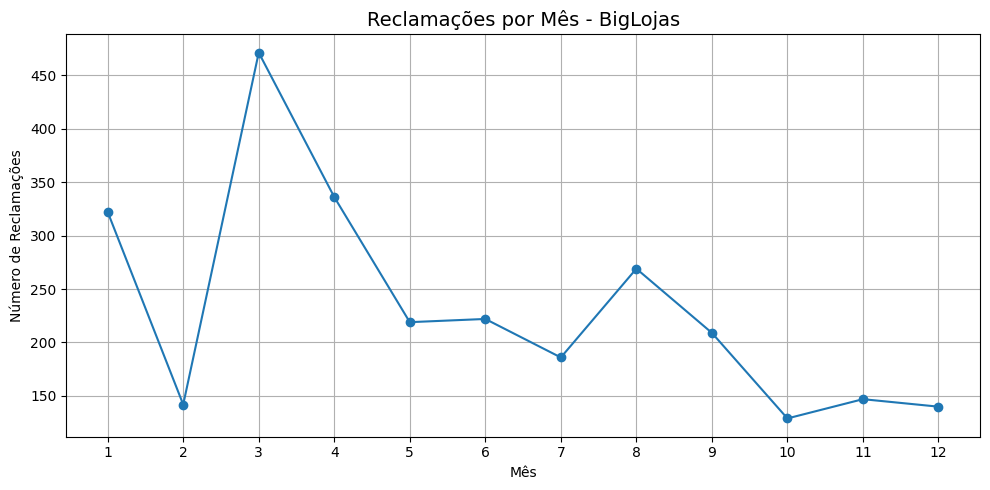

In [ ]:
# Gráfico: Reclamações por mês (sazonalidade - linha)
reclamacoes_mes = df.groupby("MES")["CASOS"].sum().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(
    reclamacoes_mes.index,
    reclamacoes_mes.values,
    marker="o"
)

plt.title("Reclamações por Mês - BigLojas", fontsize=14)
plt.xlabel("Mês")
plt.ylabel("Número de Reclamações")
plt.xticks(reclamacoes_mes.index)
plt.grid(True)
plt.tight_layout()
plt.show()

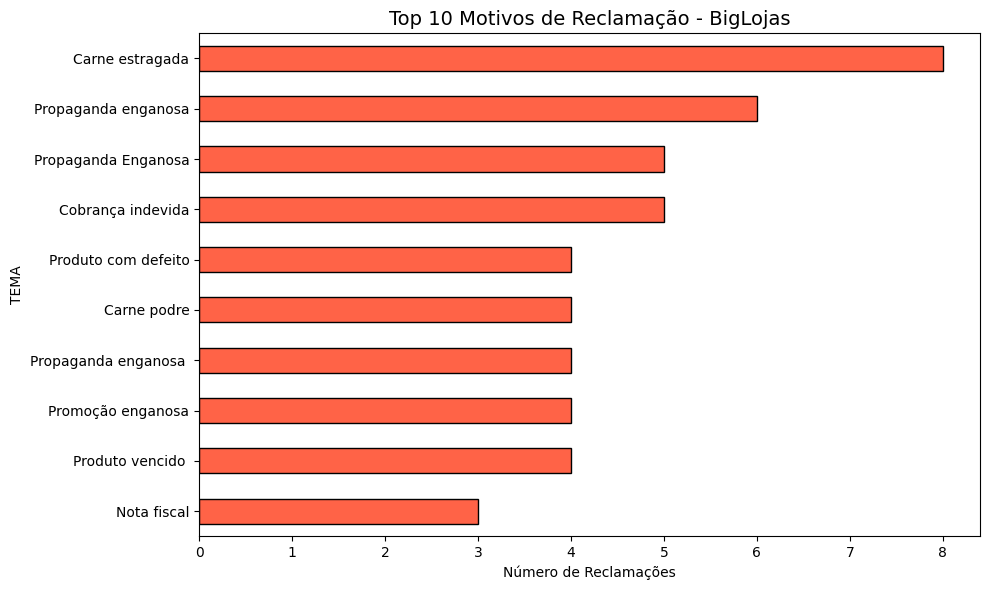

In [ ]:
# Gráfico: Top 10 motivos de reclamação
ranking_temas = df["TEMA"].value_counts().head(10)

plt.figure(figsize=(10, 6))
ranking_temas.plot(kind="barh", color="tomato", edgecolor="black")
plt.title("Top 10 Motivos de Reclamação - BigLojas", fontsize=14)
plt.xlabel("Número de Reclamações")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

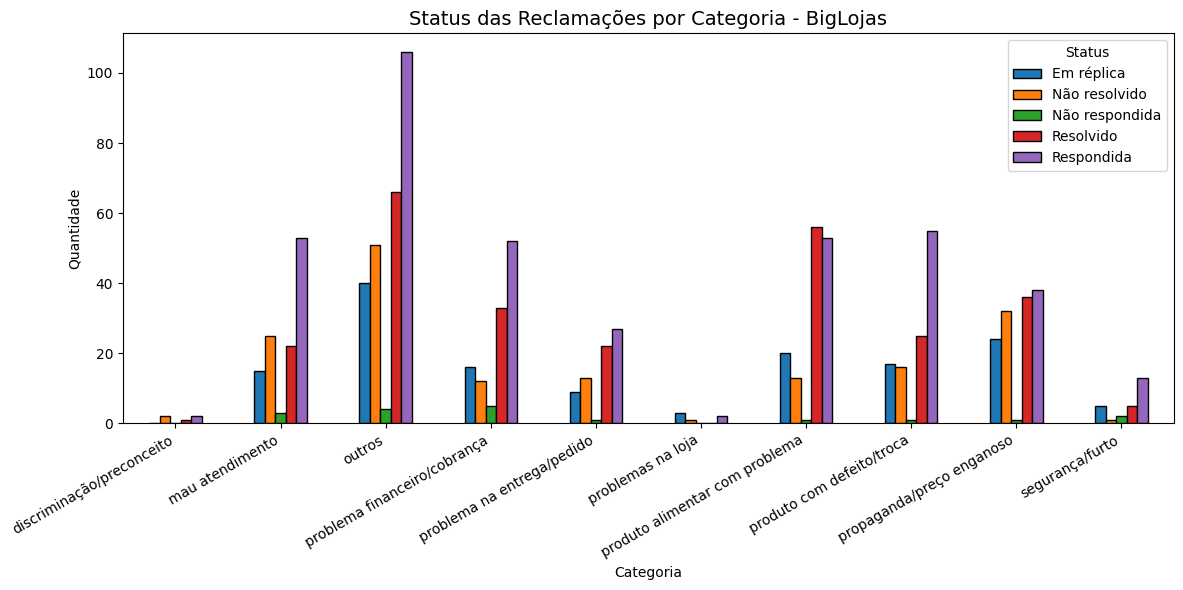

In [ ]:
# Gráfico: Cruzamento STATUS vs CATEGORIA
cruzamento = df.groupby(["TEMA_CATEGORIA", "STATUS"]).size().unstack(fill_value=0)

cruzamento.plot(kind="bar", figsize=(12, 6), edgecolor="black")
plt.title("Status das Reclamações por Categoria - BigLojas", fontsize=14)
plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

Proporção de status (%):
STATUS
Respondida        40.1
Resolvido         26.6
Não resolvido     16.6
Em réplica        14.9
Não respondida     1.8
Name: proportion, dtype: float64


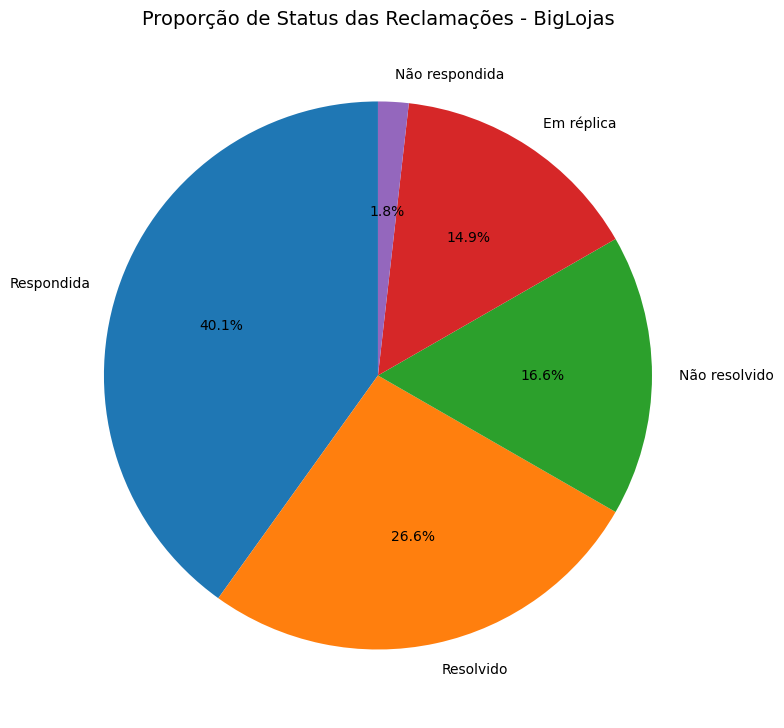

In [ ]:
# proporção de STATUS (%)
proporcao_status = df["STATUS"].value_counts(normalize=True) * 100

print("Proporção de status (%):")
print(proporcao_status.round(2))

# gráfico
plt.figure(figsize=(8, 8))
df["STATUS"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proporção de Status das Reclamações - BigLojas", fontsize=14)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 1. Extrair UF de LOCAL
# =========================
df["ESTADO"] = (
    df["LOCAL"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.extract(r'([A-Z]{2})$')
)

# remove estados não identificados
df_mapa = df.dropna(subset=["ESTADO"]).copy()

# =========================
# 2. Agregar por estado
# usar soma de CASOS
# =========================
reclamacoes_por_estado = (
    df_mapa.groupby("ESTADO", as_index=False)["CASOS"]
    .sum()
    .sort_values("CASOS", ascending=False)
)

print(reclamacoes_por_estado.head())

# =========================
# 3. Ler GeoJSON dos estados
# IMPORTANTE:
# faça upload de um arquivo geojson dos estados do Brasil
# exemplo de nome: brasil_estados.geojson
# =========================
with open("/content/brasil_estados.geojson", "r", encoding="utf-8") as f:
    geojson_br = json.load(f)

# =========================
# 4. Criar mapa
# IMPORTANTE:
# esse código assume que no geojson existe uma propriedade chamada "sigla"
# em cada estado, como "CE", "SP", "RJ" etc.
# =========================
fig = px.choropleth(
    reclamacoes_por_estado,
    geojson=geojson_br,
    locations="ESTADO",
    featureidkey="properties.sigla",
    color="CASOS",
    color_continuous_scale="Blues",
    projection="mercator",
    title="Reclamações por Estado - BigLojas"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

   ESTADO  CASOS
16     SP   1364
14     RS    530
11     PR    241
12     RJ    137
7      MG    128


FileNotFoundError: [Errno 2] No such file or directory: '/content/brasil_estados.geojson'